In [13]:
# Cell 1 - Imports and Setup

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Paths
RESULTS_PATH = Path("./evaluation_results")
OUTPUT_PATH = Path("./visualizations")
OUTPUT_PATH.mkdir(exist_ok=True)

print("="*80)
print("MODEL VISUALIZATION NOTEBOOK")
print("="*80)
print(f"\nResults path: {RESULTS_PATH}")
print(f"Output path: {OUTPUT_PATH}")

MODEL VISUALIZATION NOTEBOOK

Results path: evaluation_results
Output path: visualizations


In [2]:
# Cell 2 - Load Evaluation Results

print("\n" + "="*80)
print("LOADING EVALUATION RESULTS")
print("="*80)

# Load patch-level results
with open(RESULTS_PATH / 'x10_patch_metrics.json', 'r') as f:
    patch_x10 = json.load(f)
print("✓ Loaded: x10_patch_metrics.json")

with open(RESULTS_PATH / 'x20_patch_metrics.json', 'r') as f:
    patch_x20 = json.load(f)
print("✓ Loaded: x20_patch_metrics.json")

# Load patient-level results (mean aggregation)
with open(RESULTS_PATH / 'x10_patient_metrics_mean.json', 'r') as f:
    patient_x10_mean = json.load(f)
print("✓ Loaded: x10_patient_metrics_mean.json (mean)")

with open(RESULTS_PATH / 'x20_patient_metrics_mean.json', 'r') as f:
    patient_x20_mean = json.load(f)
print("✓ Loaded: x20_patient_metrics_mean.json (mean)")

# Load top-k results (if available)
try:
    with open(RESULTS_PATH / 'x10_patient_metrics_top30.json', 'r') as f:
        patient_x10_top30 = json.load(f)
    with open(RESULTS_PATH / 'x10_patient_metrics_top50.json', 'r') as f:
        patient_x10_top50 = json.load(f)
    with open(RESULTS_PATH / 'x20_patient_metrics_top30.json', 'r') as f:
        patient_x20_top30 = json.load(f)
    with open(RESULTS_PATH / 'x20_patient_metrics_top50.json', 'r') as f:
        patient_x20_top50 = json.load(f)
    print("✓ Loaded: Top-K pooling results")
    has_topk = True
except FileNotFoundError:
    print("⚠ Top-K results not found, will skip those visualizations")
    has_topk = False

print("\n✓ All results loaded successfully!")


LOADING EVALUATION RESULTS
✓ Loaded: x10_patch_metrics.json
✓ Loaded: x20_patch_metrics.json
✓ Loaded: x10_patient_metrics_mean.json (mean)
✓ Loaded: x20_patient_metrics_mean.json (mean)
✓ Loaded: Top-K pooling results

✓ All results loaded successfully!


In [3]:
# Cell 3 - Summary Statistics
# ============================================================================

print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)

def print_summary(mag, patch_res, patient_res):
    print(f"\n{mag.upper()} MODEL - MEAN AGGREGATION")
    print("-" * 80)
    print(f"Patch-Level  ({patch_res['n_samples']:,} patches):")
    print(f"  Accuracy: {patch_res['accuracy']:.4f} | F2: {patch_res['f2_mf']:.4f} | ROC-AUC: {patch_res['roc_auc']:.4f}")
    
    print(f"\nPatient-Level ({patient_res['n_patients']} patients):")
    print(f"  Accuracy: {patient_res['accuracy']:.4f} | F2: {patient_res['f2_mf']:.4f} | ROC-AUC: {patient_res['roc_auc']:.4f}")
    print(f"  ★ Sensitivity(MF): {patient_res['sensitivity_mf']:.4f} | Specificity(MF): {patient_res['specificity_mf']:.4f}")

print_summary('x10', patch_x10, patient_x10_mean)
print_summary('x20', patch_x20, patient_x20_mean)


EVALUATION SUMMARY

X10 MODEL - MEAN AGGREGATION
--------------------------------------------------------------------------------
Patch-Level  (12,850 patches):
  Accuracy: 0.7525 | F2: 0.7375 | ROC-AUC: 0.8581

Patient-Level (58 patients):
  Accuracy: 0.7931 | F2: 0.7955 | ROC-AUC: 0.9015
  ★ Sensitivity(MF): 0.7778 | Specificity(MF): 0.7778

X20 MODEL - MEAN AGGREGATION
--------------------------------------------------------------------------------
Patch-Level  (27,225 patches):
  Accuracy: 0.8002 | F2: 0.8661 | ROC-AUC: 0.8204

Patient-Level (59 patients):
  Accuracy: 0.8305 | F2: 0.9162 | ROC-AUC: 0.8317
  ★ Sensitivity(MF): 0.9459 | Specificity(MF): 0.9459



1. CONFUSION MATRICES


✓ Saved: visualizations\01_confusion_matrices.png


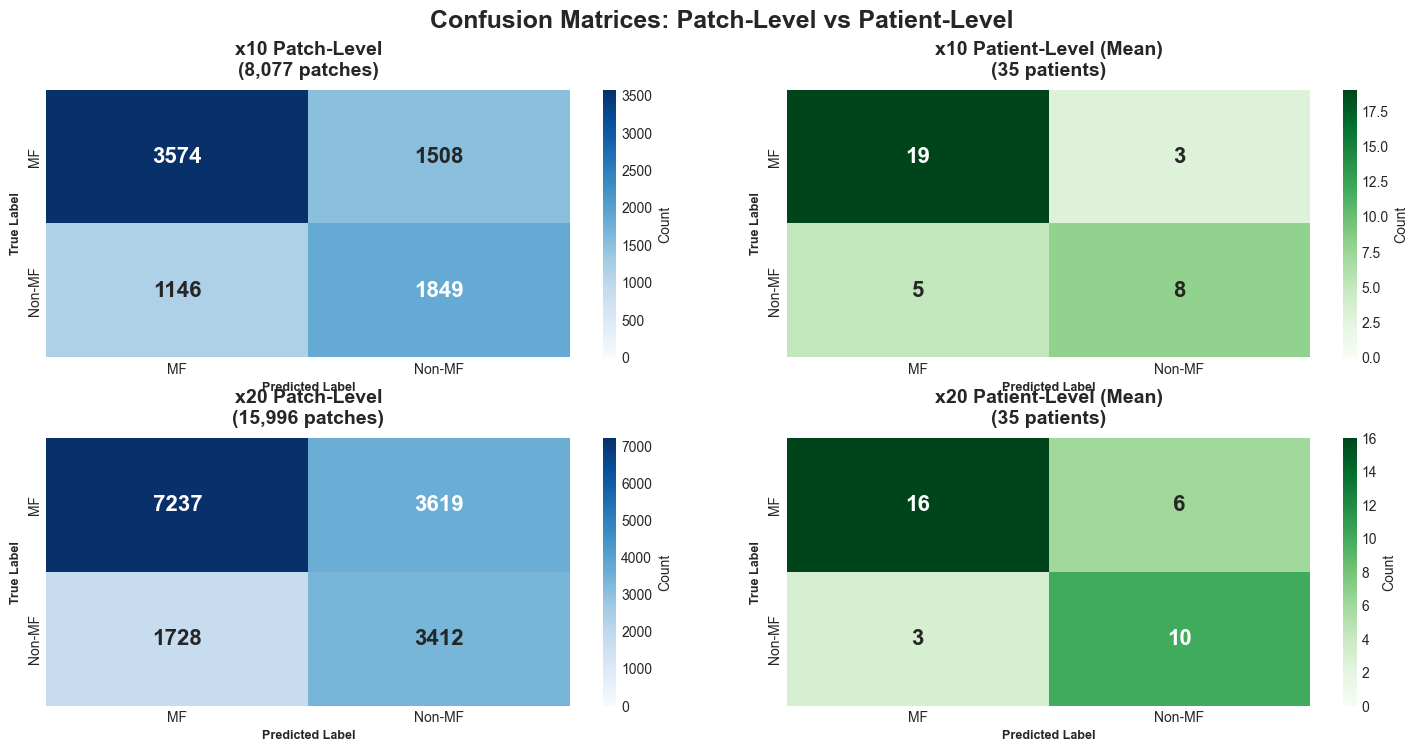

In [4]:
# Cell 4 - Main Visualization: Confusion Matrices

def plot_confusion_matrices_main(patch_x10, patient_x10, patch_x20, patient_x20, save_path=None):
    """Plot confusion matrices for both models (patch and patient level)"""
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)
    
    fig.suptitle('Confusion Matrices: Patch-Level vs Patient-Level', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    # Define color maps
    cmap_patch = 'Blues'
    cmap_patient = 'Greens'
    
    # x10 Patch-level
    ax1 = fig.add_subplot(gs[0, 0:2])
    cm = np.array(patch_x10['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_patch, 
                xticklabels=['MF', 'Non-MF'], yticklabels=['MF', 'Non-MF'],
                ax=ax1, cbar_kws={'label': 'Count'}, 
                annot_kws={'size': 16, 'weight': 'bold'},
                vmin=0, vmax=cm.max())
    ax1.set_xlabel('Predicted Label', fontsize=9, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=9, fontweight='bold')
    ax1.set_title(f'x10 Patch-Level\n({patch_x10["n_samples"]:,} patches)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # x10 Patient-level
    ax2 = fig.add_subplot(gs[0, 2:4])
    cm = np.array(patient_x10['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_patient, 
                xticklabels=['MF', 'Non-MF'], yticklabels=['MF', 'Non-MF'],
                ax=ax2, cbar_kws={'label': 'Count'}, 
                annot_kws={'size': 16, 'weight': 'bold'},
                vmin=0, vmax=cm.max())
    ax2.set_xlabel('Predicted Label', fontsize=9, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=9, fontweight='bold')
    ax2.set_title(f'x10 Patient-Level (Mean)\n({patient_x10["n_patients"]} patients)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # x20 Patch-level
    ax3 = fig.add_subplot(gs[1, 0:2])
    cm = np.array(patch_x20['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_patch, 
                xticklabels=['MF', 'Non-MF'], yticklabels=['MF', 'Non-MF'],
                ax=ax3, cbar_kws={'label': 'Count'}, 
                annot_kws={'size': 16, 'weight': 'bold'},
                vmin=0, vmax=cm.max())
    ax3.set_xlabel('Predicted Label', fontsize=9, fontweight='bold')
    ax3.set_ylabel('True Label', fontsize=9, fontweight='bold')
    ax3.set_title(f'x20 Patch-Level\n({patch_x20["n_samples"]:,} patches)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # x20 Patient-level
    ax4 = fig.add_subplot(gs[1, 2:4])
    cm = np.array(patient_x20['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_patient, 
                xticklabels=['MF', 'Non-MF'], yticklabels=['MF', 'Non-MF'],
                ax=ax4, cbar_kws={'label': 'Count'}, 
                annot_kws={'size': 16, 'weight': 'bold'},
                vmin=0, vmax=cm.max())
    ax4.set_xlabel('Predicted Label', fontsize=9, fontweight='bold')
    ax4.set_ylabel('True Label', fontsize=9, fontweight='bold')
    ax4.set_title(f'x20 Patient-Level (Mean)\n({patient_x20["n_patients"]} patients)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
    plt.show()

print("\n" + "="*80)
print("1. CONFUSION MATRICES")
print("="*80)
plot_confusion_matrices_main(patch_x10, patient_x10_mean, patch_x20, patient_x20_mean,
                             save_path=OUTPUT_PATH / '01_confusion_matrices.png')



2. F2 SCORE ANALYSIS (PRIMARY METRIC)
✓ Saved: visualizations\02_f2_scores.png


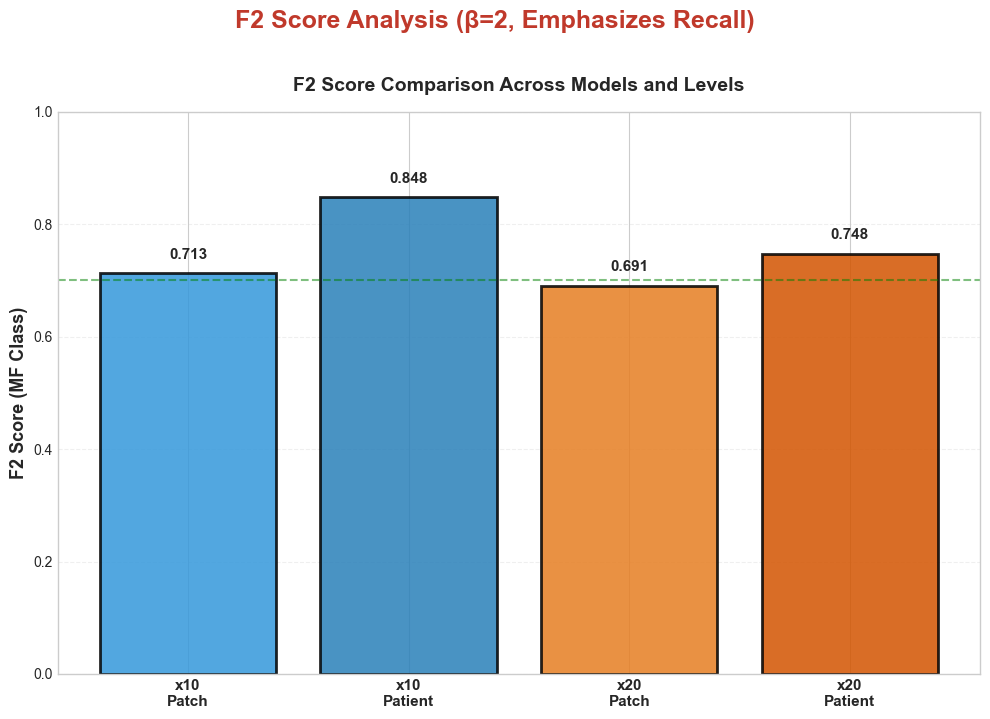

In [5]:
# Cell 5 - F2 Score Visualization (Primary Metric - Simplified)

def plot_f2_scores(patch_x10, patient_x10, patch_x20, patient_x20, save_path=None):
    """Plot F2 score comparison across models and levels (MF class only)"""
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    fig.suptitle(
        'F2 Score Analysis (β=2, Emphasizes Recall)', 
        fontsize=18, fontweight='bold', color='#c0392b', y=1.02
    )

    # Prepare data
    x_pos = np.arange(4)
    f2_values = [
        patch_x10['f2_mf'], patient_x10['f2_mf'],
        patch_x20['f2_mf'], patient_x20['f2_mf']
    ]
    labels = ['x10\nPatch', 'x10\nPatient', 'x20\nPatch', 'x20\nPatient']
    bar_colors = ['#3498db', '#2980b9', '#e67e22', '#d35400']

    bars = ax.bar(
        x_pos, f2_values,
        color=bar_colors, alpha=0.85,
        edgecolor='black', linewidth=2
    )

    ax.set_ylabel('F2 Score (MF Class)', fontsize=13, fontweight='bold')
    ax.set_title(
        'F2 Score Comparison Across Models and Levels',
        fontsize=14, fontweight='bold', pad=15
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.axhline(
        y=0.7, color='green',
        linestyle='--', linewidth=1.5, alpha=0.5
    )

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.02,
            f'{height:.3f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=11
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
    plt.show()


print("\n" + "="*80)
print("2. F2 SCORE ANALYSIS (PRIMARY METRIC)")
print("="*80)
plot_f2_scores(
    patch_x10, patient_x10_mean,
    patch_x20, patient_x20_mean,
    save_path=OUTPUT_PATH / '02_f2_scores.png'
)



3. ROC CURVES
✓ Saved: visualizations\03_roc_curves.png


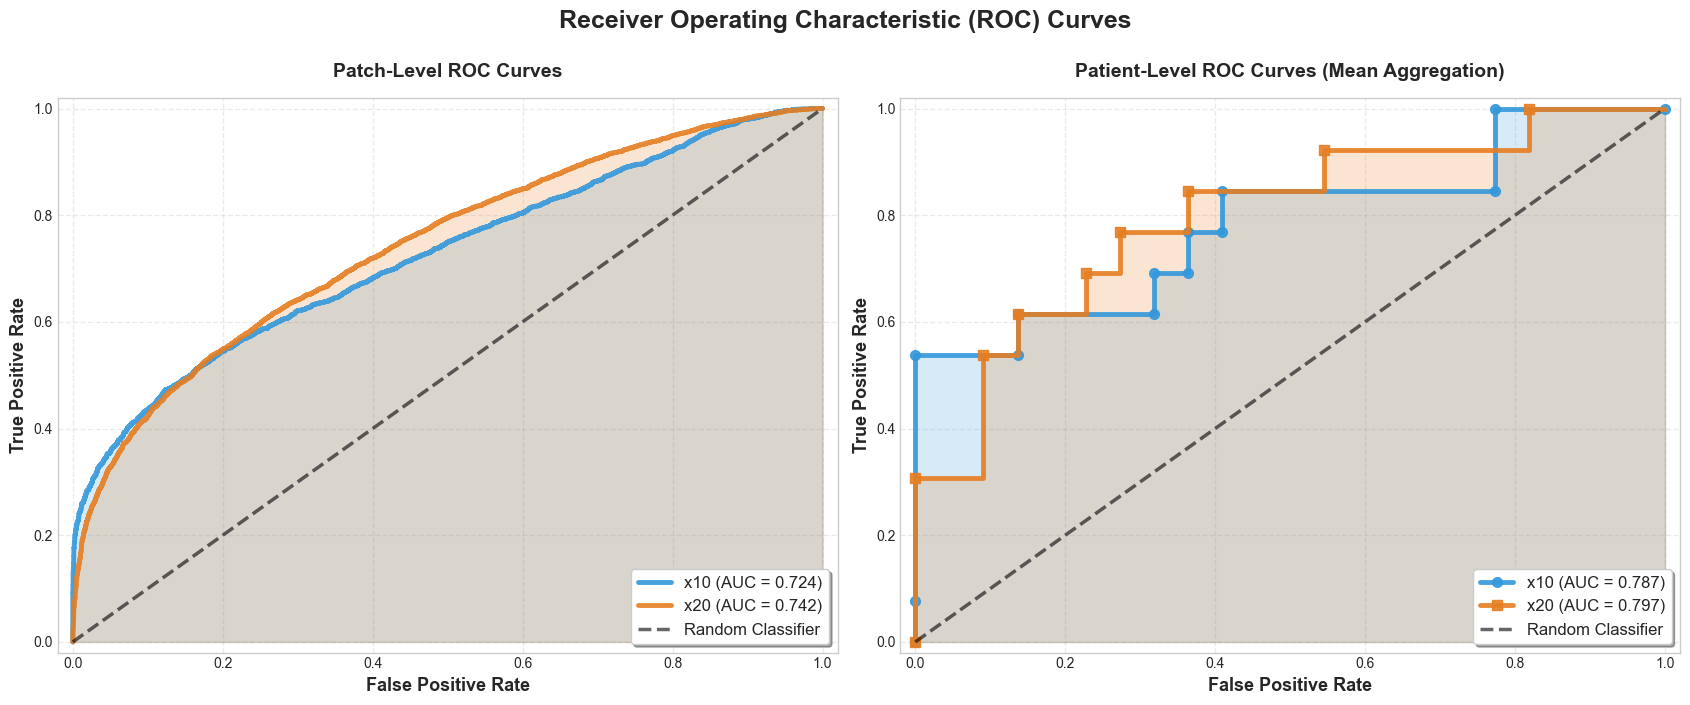

In [6]:
# Cell 6 - ROC Curves

def plot_roc_curves(patch_x10, patient_x10, patch_x20, patient_x20, save_path=None):
    """Plot ROC curves for all models"""
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    fig.suptitle('Receiver Operating Characteristic (ROC) Curves', 
                 fontsize=18, fontweight='bold', y=1.0)
    
    # Patch-level ROC
    ax = axes[0]
    fpr_10 = np.array(patch_x10['roc_curve']['fpr'])
    tpr_10 = np.array(patch_x10['roc_curve']['tpr'])
    fpr_20 = np.array(patch_x20['roc_curve']['fpr'])
    tpr_20 = np.array(patch_x20['roc_curve']['tpr'])
    
    ax.plot(fpr_10, tpr_10, linewidth=3.5, label=f'x10 (AUC = {patch_x10["roc_auc"]:.3f})', 
            color='#3498db', alpha=0.9)
    ax.plot(fpr_20, tpr_20, linewidth=3.5, label=f'x20 (AUC = {patch_x20["roc_auc"]:.3f})', 
            color='#e67e22', alpha=0.9)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2.5, label='Random Classifier', alpha=0.6)
    
    ax.fill_between(fpr_10, tpr_10, alpha=0.2, color='#3498db')
    ax.fill_between(fpr_20, tpr_20, alpha=0.2, color='#e67e22')
    
    ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    ax.set_title('Patch-Level ROC Curves', fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # Patient-level ROC
    ax = axes[1]
    fpr_10 = np.array(patient_x10['roc_curve']['fpr'])
    tpr_10 = np.array(patient_x10['roc_curve']['tpr'])
    fpr_20 = np.array(patient_x20['roc_curve']['fpr'])
    tpr_20 = np.array(patient_x20['roc_curve']['tpr'])
    
    ax.plot(fpr_10, tpr_10, linewidth=3.5, label=f'x10 (AUC = {patient_x10["roc_auc"]:.3f})', 
            color='#3498db', alpha=0.9, marker='o', markersize=7, 
            markevery=max(1, len(fpr_10)//8))
    ax.plot(fpr_20, tpr_20, linewidth=3.5, label=f'x20 (AUC = {patient_x20["roc_auc"]:.3f})', 
            color='#e67e22', alpha=0.9, marker='s', markersize=7, 
            markevery=max(1, len(fpr_20)//8))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2.5, label='Random Classifier', alpha=0.6)
    
    ax.fill_between(fpr_10, tpr_10, alpha=0.2, color='#3498db')
    ax.fill_between(fpr_20, tpr_20, alpha=0.2, color='#e67e22')
    
    ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    ax.set_title('Patient-Level ROC Curves (Mean Aggregation)', fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
    plt.show()

print("\n" + "="*80)
print("3. ROC CURVES")
print("="*80)
plot_roc_curves(patch_x10, patient_x10_mean, patch_x20, patient_x20_mean,
                save_path=OUTPUT_PATH / '03_roc_curves.png')


4. PRECISION-RECALL CURVES
✓ Saved: visualizations\04_pr_curves.png


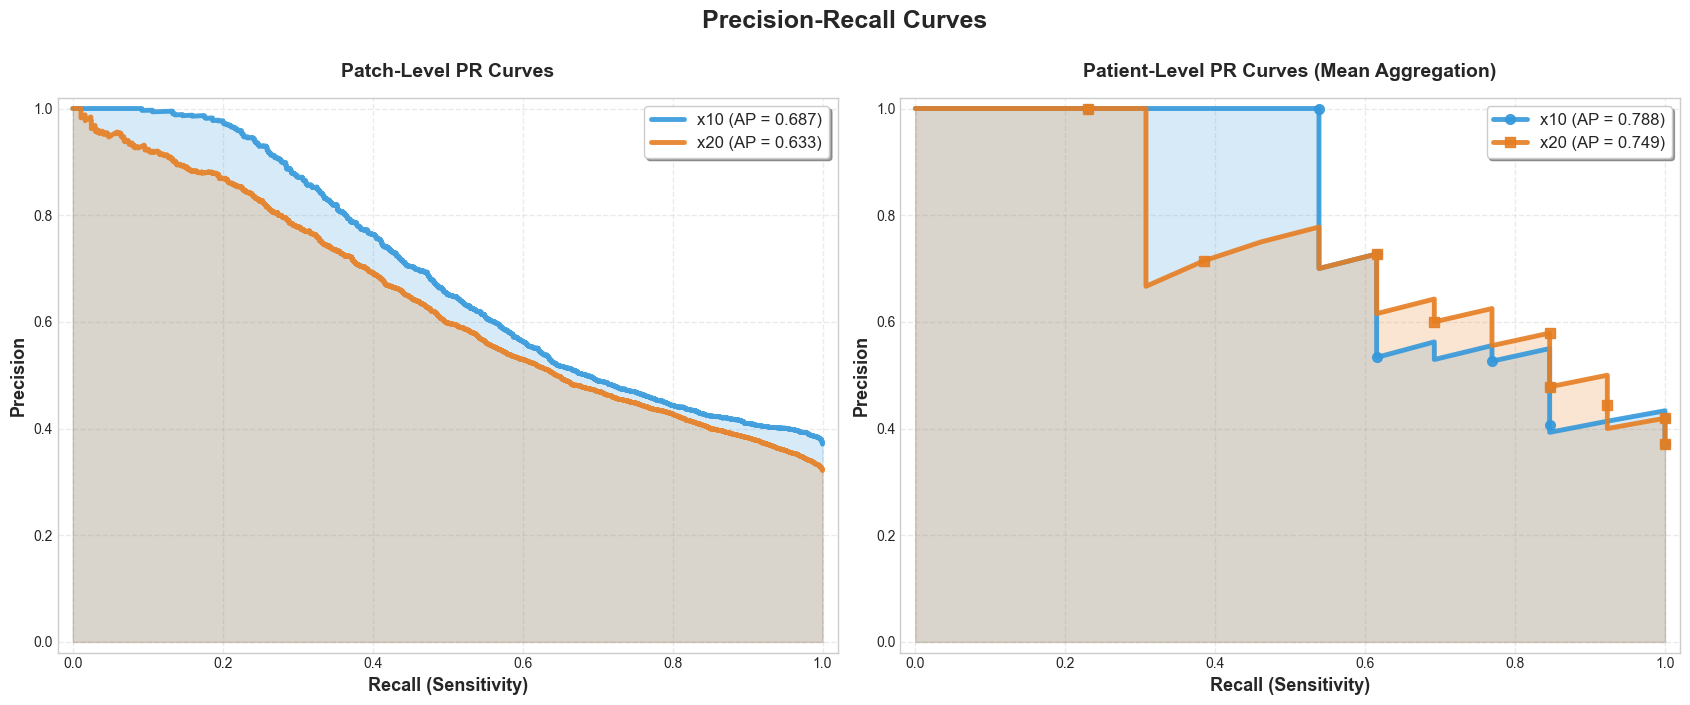

In [7]:
# Cell 7 - Precision-Recall Curves

def plot_pr_curves(patch_x10, patient_x10, patch_x20, patient_x20, save_path=None):
    """Plot Precision-Recall curves"""
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    fig.suptitle('Precision-Recall Curves', 
                 fontsize=18, fontweight='bold', y=1.0)
    
    # Patch-level PR
    ax = axes[0]
    prec_10 = np.array(patch_x10['pr_curve']['precision'])
    rec_10 = np.array(patch_x10['pr_curve']['recall'])
    prec_20 = np.array(patch_x20['pr_curve']['precision'])
    rec_20 = np.array(patch_x20['pr_curve']['recall'])
    
    ax.plot(rec_10, prec_10, linewidth=3.5, label=f'x10 (AP = {patch_x10["pr_auc"]:.3f})', 
            color='#3498db', alpha=0.9)
    ax.plot(rec_20, prec_20, linewidth=3.5, label=f'x20 (AP = {patch_x20["pr_auc"]:.3f})', 
            color='#e67e22', alpha=0.9)
    
    ax.fill_between(rec_10, prec_10, alpha=0.2, color='#3498db')
    ax.fill_between(rec_20, prec_20, alpha=0.2, color='#e67e22')
    
    ax.set_xlabel('Recall (Sensitivity)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title('Patch-Level PR Curves', fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # Patient-level PR
    ax = axes[1]
    prec_10 = np.array(patient_x10['pr_curve']['precision'])
    rec_10 = np.array(patient_x10['pr_curve']['recall'])
    prec_20 = np.array(patient_x20['pr_curve']['precision'])
    rec_20 = np.array(patient_x20['pr_curve']['recall'])
    
    ax.plot(rec_10, prec_10, linewidth=3.5, label=f'x10 (AP = {patient_x10["pr_auc"]:.3f})', 
            color='#3498db', alpha=0.9, marker='o', markersize=7,
            markevery=max(1, len(rec_10)//8))
    ax.plot(rec_20, prec_20, linewidth=3.5, label=f'x20 (AP = {patient_x20["pr_auc"]:.3f})', 
            color='#e67e22', alpha=0.9, marker='s', markersize=7,
            markevery=max(1, len(rec_20)//8))
    
    ax.fill_between(rec_10, prec_10, alpha=0.2, color='#3498db')
    ax.fill_between(rec_20, prec_20, alpha=0.2, color='#e67e22')
    
    ax.set_xlabel('Recall (Sensitivity)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title('Patient-Level PR Curves (Mean Aggregation)', fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
    plt.show()

print("\n" + "="*80)
print("4. PRECISION-RECALL CURVES")
print("="*80)
plot_pr_curves(patch_x10, patient_x10_mean, patch_x20, patient_x20_mean,
               save_path=OUTPUT_PATH / '04_pr_curves.png')


5. COMPREHENSIVE METRICS DASHBOARD
✓ Saved: visualizations\05_metrics_dashboard.png


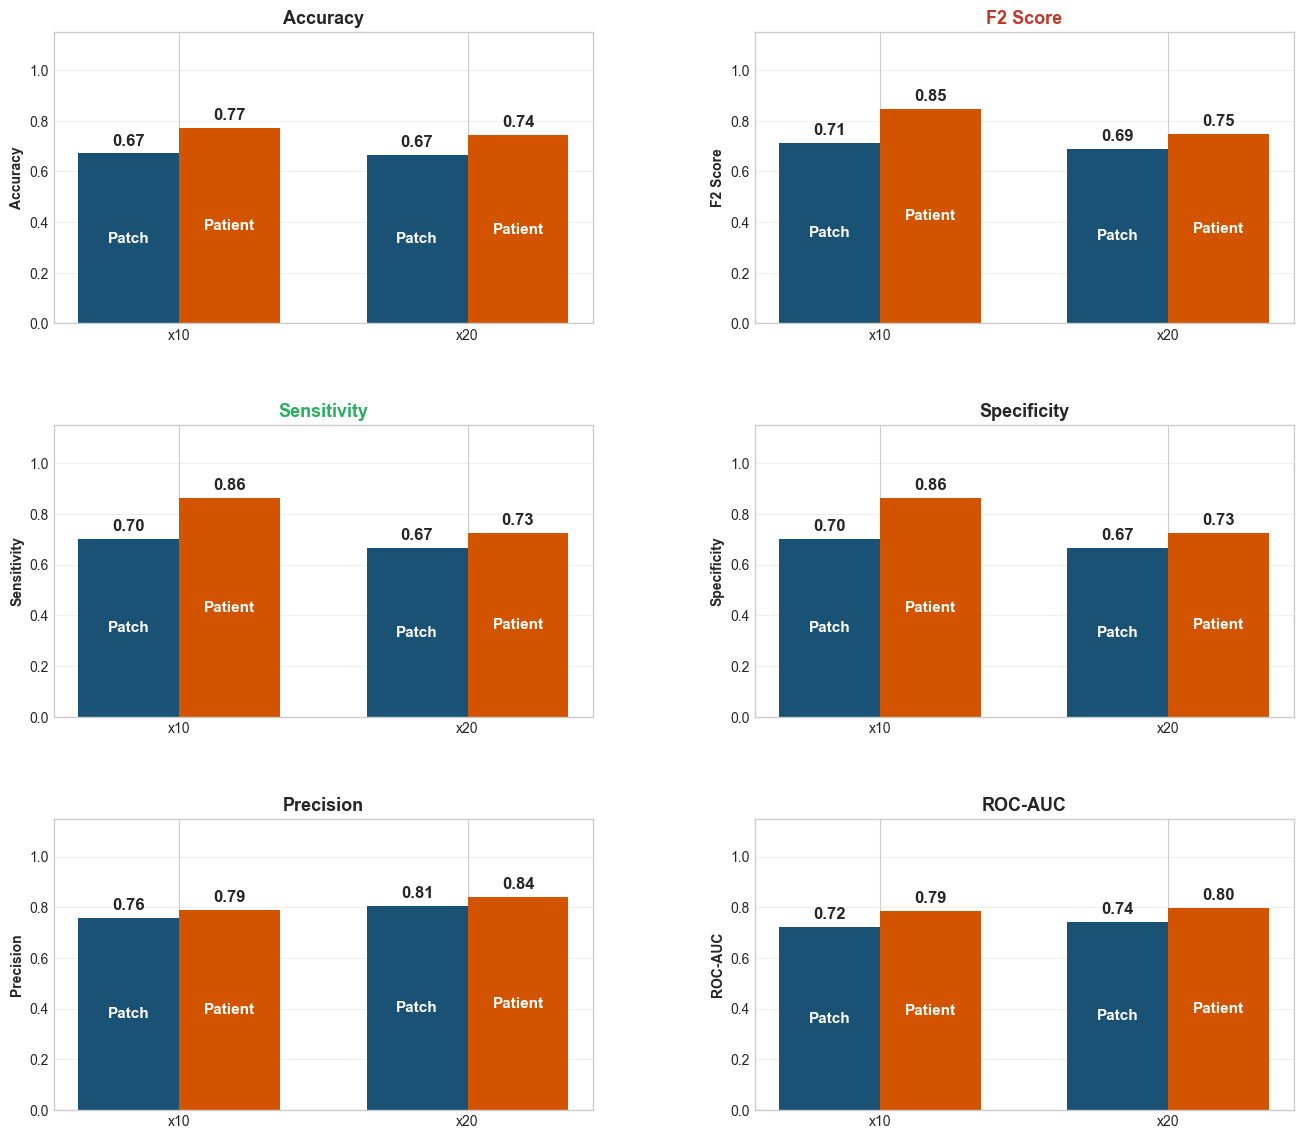

In [16]:
# Cell 8 - Comprehensive Metrics Dashboard

def plot_metrics_dashboard(patch_x10, patient_x10, patch_x20, patient_x20, save_path=None):
    """Comprehensive metrics comparison dashboard"""
    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    models = ['x10', 'x20']
    x = np.arange(len(models))
    width = 0.35
    
    # Colors: dark blue for Patch, dark orange for Patient
    patch_color = '#1a5276'   # Dark blue
    patient_color = '#d35400' # Dark orange
    
    def add_bar_labels(ax, bars1, bars2):
        """Add labels on bars and values on top"""
        # Add "Patch" label on patch bars
        for bar in bars1:
            h = bar.get_height()
            # Label on the bar
            ax.text(bar.get_x() + bar.get_width()/2., h/2, 'Patch',
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
            # Value on top
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
        # Add "Patient" label on patient bars
        for bar in bars2:
            h = bar.get_height()
            # Label on the bar
            ax.text(bar.get_x() + bar.get_width()/2., h/2, 'Patient',
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
            # Value on top
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # 1. Accuracy
    ax1 = fig.add_subplot(gs[0, 0])
    patch_acc = [patch_x10['accuracy'], patch_x20['accuracy']]
    patient_acc = [patient_x10['accuracy'], patient_x20['accuracy']]
    bars1 = ax1.bar(x - width/2, patch_acc, width, color=patch_color)
    bars2 = ax1.bar(x + width/2, patient_acc, width, color=patient_color)
    ax1.set_ylabel('Accuracy', fontweight='bold')
    ax1.set_title('Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models)
    ax1.set_ylim([0, 1.15])
    ax1.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax1, bars1, bars2)
    
    # 2. F2 Score (MF)
    ax2 = fig.add_subplot(gs[0, 1])
    patch_f2 = [patch_x10['f2_mf'], patch_x20['f2_mf']]
    patient_f2 = [patient_x10['f2_mf'], patient_x20['f2_mf']]
    bars1 = ax2.bar(x - width/2, patch_f2, width, color=patch_color)
    bars2 = ax2.bar(x + width/2, patient_f2, width, color=patient_color)
    ax2.set_ylabel('F2 Score', fontweight='bold')
    ax2.set_title('F2 Score', fontsize=13, fontweight='bold', color='#c0392b')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models)
    ax2.set_ylim([0, 1.15])
    ax2.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax2, bars1, bars2)
    
    # 3. Sensitivity (Recall - MF)
    ax3 = fig.add_subplot(gs[1, 0])
    patch_sens = [patch_x10['recall_mf'], patch_x20['recall_mf']]
    patient_sens = [patient_x10['sensitivity_mf'], patient_x20['sensitivity_mf']]
    bars1 = ax3.bar(x - width/2, patch_sens, width, color=patch_color)
    bars2 = ax3.bar(x + width/2, patient_sens, width, color=patient_color)
    ax3.set_ylabel('Sensitivity', fontweight='bold')
    ax3.set_title('Sensitivity', fontsize=13, fontweight='bold', color='#27ae60')
    ax3.set_xticks(x)
    ax3.set_xticklabels(models)
    ax3.set_ylim([0, 1.15])
    ax3.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax3, bars1, bars2)
    
    # 4. Specificity (MF)
    ax4 = fig.add_subplot(gs[1, 1])
    patch_spec = [patch_x10['specificity_mf'], patch_x20['specificity_mf']]
    patient_spec = [patient_x10['specificity_mf'], patient_x20['specificity_mf']]
    bars1 = ax4.bar(x - width/2, patch_spec, width, color=patch_color)
    bars2 = ax4.bar(x + width/2, patient_spec, width, color=patient_color)
    ax4.set_ylabel('Specificity', fontweight='bold')
    ax4.set_title('Specificity', fontsize=13, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(models)
    ax4.set_ylim([0, 1.15])
    ax4.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax4, bars1, bars2)
    
    # 5. Precision (MF)
    ax5 = fig.add_subplot(gs[2, 0])
    patch_prec = [patch_x10['precision_mf'], patch_x20['precision_mf']]
    patient_prec = [patient_x10['precision_mf'], patient_x20['precision_mf']]
    bars1 = ax5.bar(x - width/2, patch_prec, width, color=patch_color)
    bars2 = ax5.bar(x + width/2, patient_prec, width, color=patient_color)
    ax5.set_ylabel('Precision', fontweight='bold')
    ax5.set_title('Precision', fontsize=13, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(models)
    ax5.set_ylim([0, 1.15])
    ax5.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax5, bars1, bars2)
    
    # 6. ROC-AUC
    ax6 = fig.add_subplot(gs[2, 1])
    patch_auc = [patch_x10['roc_auc'], patch_x20['roc_auc']]
    patient_auc = [patient_x10['roc_auc'], patient_x20['roc_auc']]
    bars1 = ax6.bar(x - width/2, patch_auc, width, color=patch_color)
    bars2 = ax6.bar(x + width/2, patient_auc, width, color=patient_color)
    ax6.set_ylabel('ROC-AUC', fontweight='bold')
    ax6.set_title('ROC-AUC', fontsize=13, fontweight='bold')
    ax6.set_xticks(x)
    ax6.set_xticklabels(models)
    ax6.set_ylim([0, 1.15])
    ax6.grid(True, alpha=0.3, axis='y')
    add_bar_labels(ax6, bars1, bars2)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
    plt.show()

print("\n" + "="*80)
print("5. COMPREHENSIVE METRICS DASHBOARD")
print("="*80)
plot_metrics_dashboard(patch_x10, patient_x10_mean, patch_x20, patient_x20_mean,
                       save_path=OUTPUT_PATH / '05_metrics_dashboard.png')


LATE FUSION MODEL VISUALIZATION
✓ Loaded: late_fusion_results.json
✓ Saved: visualizations\07_late_fusion_dashboard.png


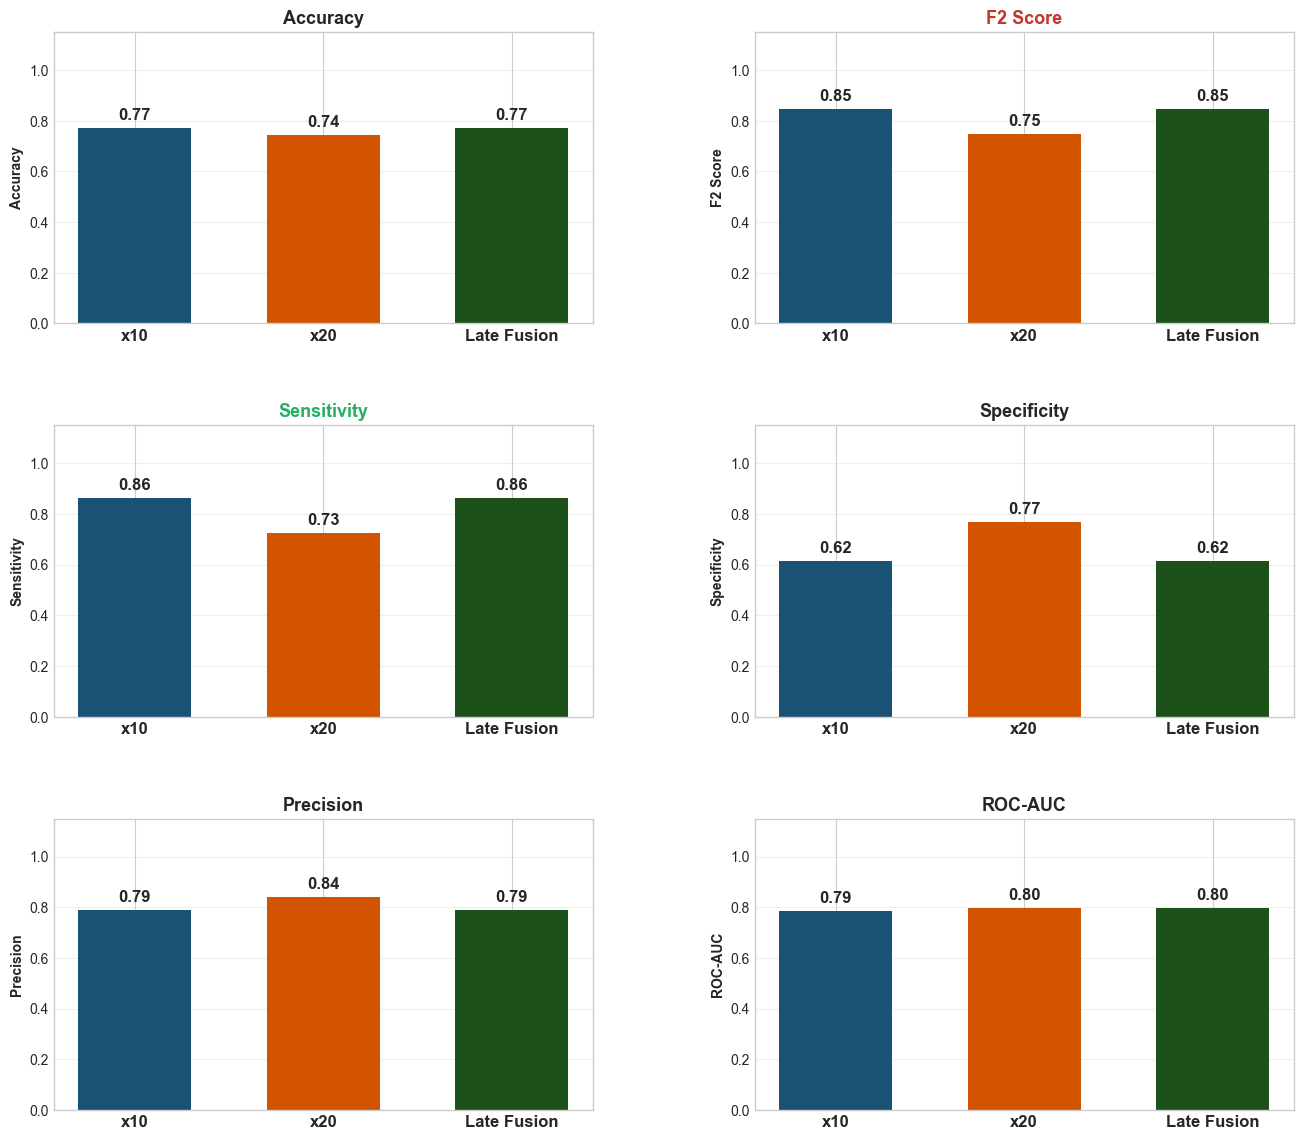

In [21]:
# Cell 9 - Late Fusion Metrics Dashboard

print("\n" + "="*80)
print("LATE FUSION MODEL VISUALIZATION")
print("="*80)

late_fusion_files = sorted(RESULTS_PATH.glob("*late*fusion*.json"))
if not late_fusion_files:
    print("⚠ No late fusion results found in evaluation_results.")
else:
    late_fusion_path = late_fusion_files[0]
    with open(late_fusion_path, "r") as f:
        late_fusion = json.load(f)
    print(f"✓ Loaded: {late_fusion_path.name}")

    def plot_late_fusion_dashboard(late_fusion, save_path=None):
        """Late fusion metrics comparison dashboard - same style as metrics dashboard"""
        fig = plt.figure(figsize=(16, 14))
        gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
        
        # Extract metrics for each model
        x10 = late_fusion['metrics']['x10_only']
        x20 = late_fusion['metrics']['x20_only']
        fused = late_fusion['metrics']['fused']
        
        models = ['x10', 'x20', 'Late Fusion']
        x = np.arange(len(models))
        width = 0.6
        
        # Colors for each model
        colors = ['#1a5276', '#d35400', "#1c5219"]  # Dark blue, Dark orange, Dark green
        
        def add_bar_labels(ax, bars):
            """Add values on top of bars"""
            for bar in bars:
                h = bar.get_height()
                # Value on top
                ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
                        ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # 1. Accuracy
        ax1 = fig.add_subplot(gs[0, 0])
        values = [x10['accuracy'], x20['accuracy'], fused['accuracy']]
        bars = ax1.bar(x, values, width, color=colors)
        ax1.set_ylabel('Accuracy', fontweight='bold')
        ax1.set_title('Accuracy', fontsize=13, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax1.set_ylim([0, 1.15])
        ax1.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax1, bars)
        
        # 2. F2 Score (MF) - need to calculate from precision and recall
        ax2 = fig.add_subplot(gs[0, 1])
        # F2 = (1 + 4) * precision * recall / (4 * precision + recall)
        def calc_f2(prec, rec):
            if prec + rec == 0:
                return 0
            return (1 + 4) * prec * rec / (4 * prec + rec)
        f2_values = [
            calc_f2(x10['precision_mf'], x10['sensitivity_mf']),
            calc_f2(x20['precision_mf'], x20['sensitivity_mf']),
            calc_f2(fused['precision_mf'], fused['sensitivity_mf'])
        ]
        bars = ax2.bar(x, f2_values, width, color=colors)
        ax2.set_ylabel('F2 Score', fontweight='bold')
        ax2.set_title('F2 Score', fontsize=13, fontweight='bold', color='#c0392b')
        ax2.set_xticks(x)
        ax2.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax2.set_ylim([0, 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax2, bars)
        
        # 3. Sensitivity (MF)
        ax3 = fig.add_subplot(gs[1, 0])
        values = [x10['sensitivity_mf'], x20['sensitivity_mf'], fused['sensitivity_mf']]
        bars = ax3.bar(x, values, width, color=colors)
        ax3.set_ylabel('Sensitivity', fontweight='bold')
        ax3.set_title('Sensitivity', fontsize=13, fontweight='bold', color='#27ae60')
        ax3.set_xticks(x)
        ax3.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax3.set_ylim([0, 1.15])
        ax3.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax3, bars)
        
        # 4. Specificity (MF)
        ax4 = fig.add_subplot(gs[1, 1])
        values = [x10['specificity_mf'], x20['specificity_mf'], fused['specificity_mf']]
        bars = ax4.bar(x, values, width, color=colors)
        ax4.set_ylabel('Specificity', fontweight='bold')
        ax4.set_title('Specificity', fontsize=13, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax4.set_ylim([0, 1.15])
        ax4.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax4, bars)
        
        # 5. Precision (MF)
        ax5 = fig.add_subplot(gs[2, 0])
        values = [x10['precision_mf'], x20['precision_mf'], fused['precision_mf']]
        bars = ax5.bar(x, values, width, color=colors)
        ax5.set_ylabel('Precision', fontweight='bold')
        ax5.set_title('Precision', fontsize=13, fontweight='bold')
        ax5.set_xticks(x)
        ax5.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax5.set_ylim([0, 1.15])
        ax5.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax5, bars)
        
        # 6. ROC-AUC
        ax6 = fig.add_subplot(gs[2, 1])
        values = [x10['roc_auc'], x20['roc_auc'], fused['roc_auc']]
        bars = ax6.bar(x, values, width, color=colors)
        ax6.set_ylabel('ROC-AUC', fontweight='bold')
        ax6.set_title('ROC-AUC', fontsize=13, fontweight='bold')
        ax6.set_xticks(x)
        ax6.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax6.set_ylim([0, 1.15])
        ax6.grid(True, alpha=0.3, axis='y')
        add_bar_labels(ax6, bars)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Saved: {save_path}")
        plt.show()

    plot_late_fusion_dashboard(late_fusion, save_path=OUTPUT_PATH / '07_late_fusion_dashboard.png')


6. TOP-K POOLING COMPARISON
✓ Saved: visualizations\06_topk_comparison.png


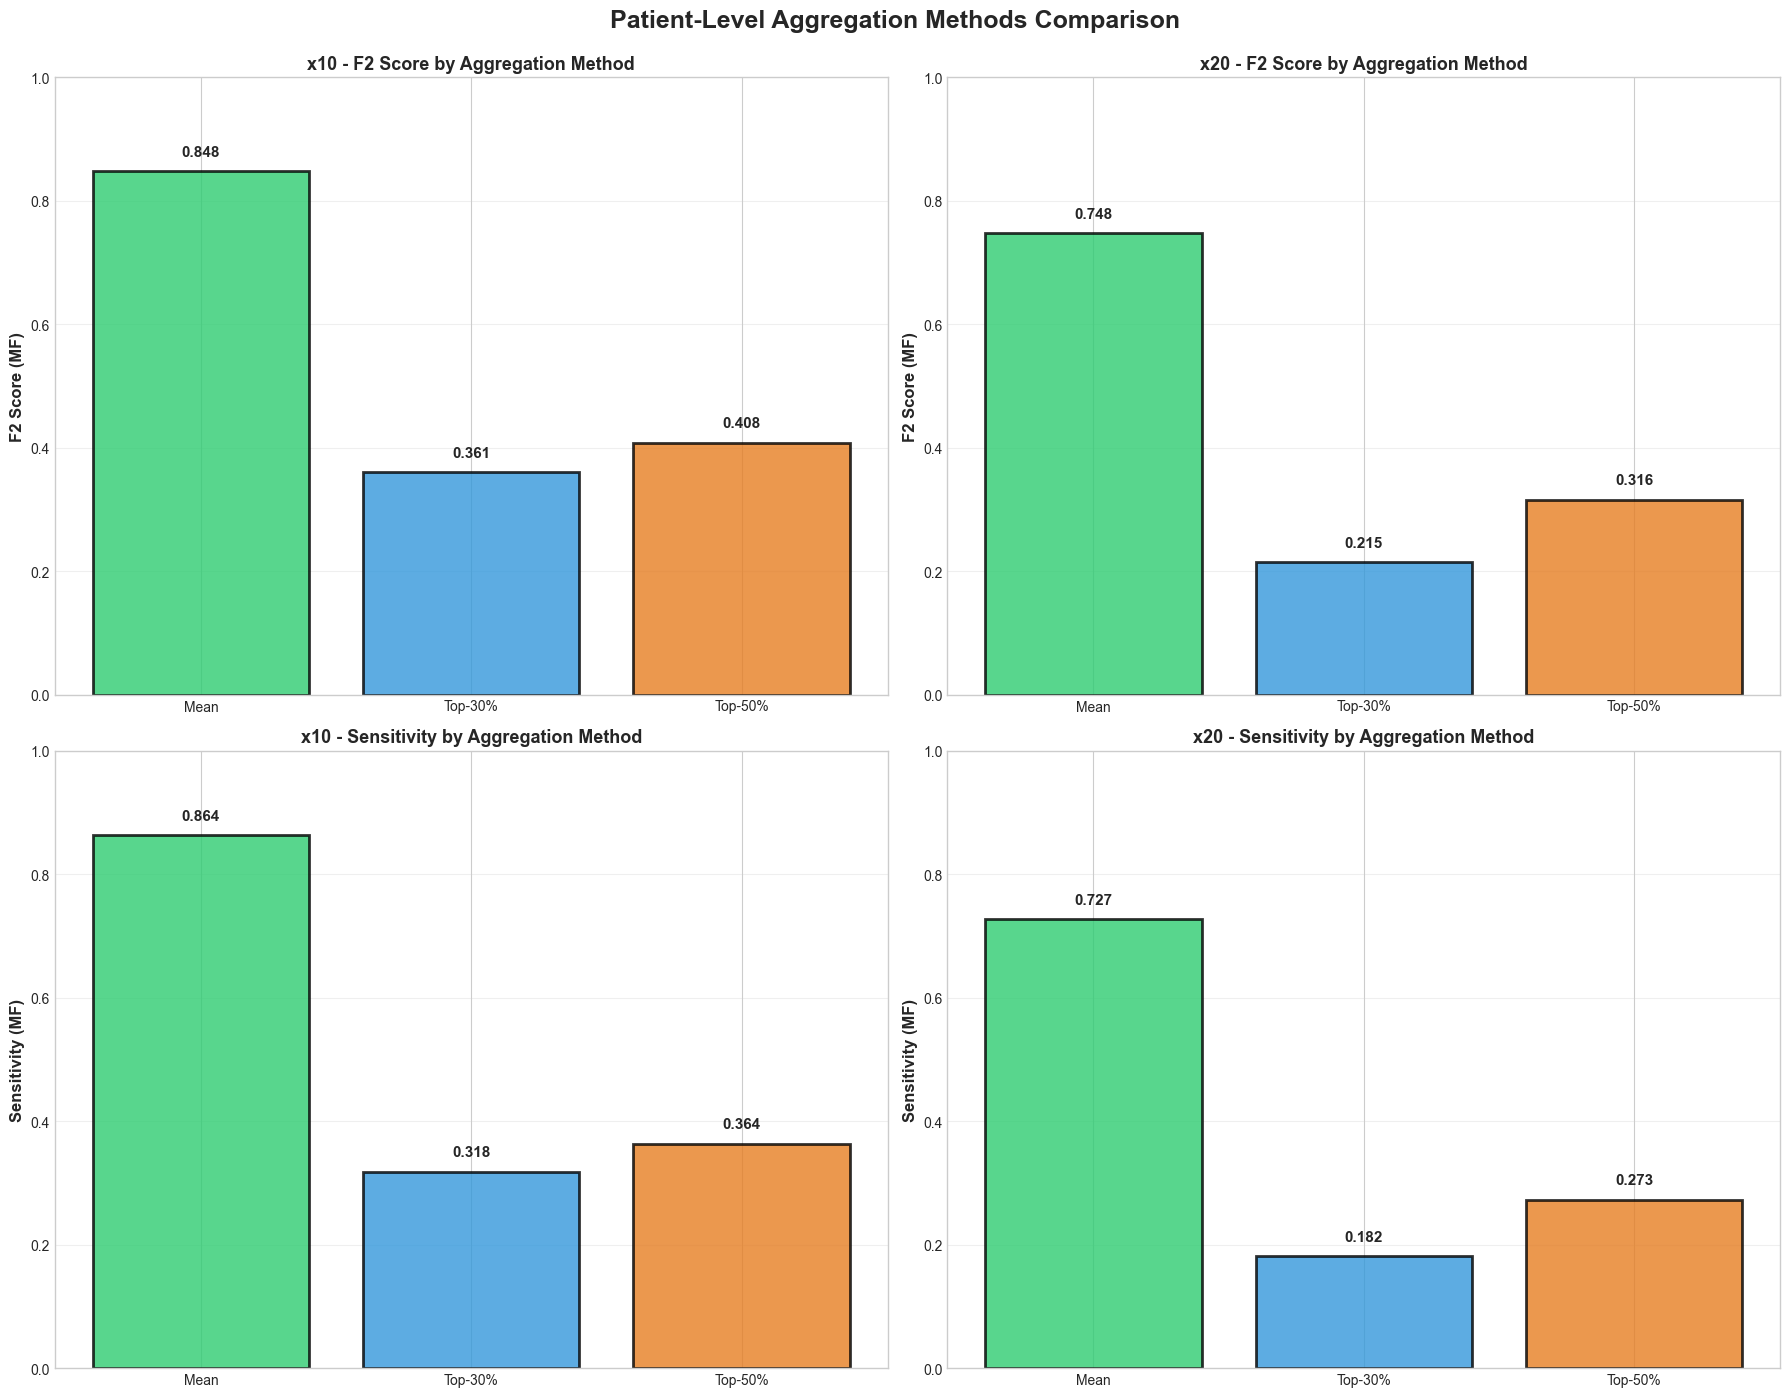


--------------------------------------------------------------------------------
AGGREGATION METHOD COMPARISON
--------------------------------------------------------------------------------

X10:
Method       Accuracy   F2(MF)     Sens(MF)   Spec(MF)   ROC-AUC   
----------------------------------------------------------------------
Mean         0.7931     0.7955     0.7778     0.7778     0.9015    
Top-30%      0.5143     0.3608     0.3182     0.3182     0.7832    
Top-50%      0.5429     0.4082     0.3636     0.3636     0.7832    

X20:
Method       Accuracy   F2(MF)     Sens(MF)   Spec(MF)   ROC-AUC   
----------------------------------------------------------------------
Mean         0.8305     0.9162     0.9459     0.9459     0.8317    
Top-30%      0.4571     0.2151     0.1818     0.1818     0.8077    
Top-50%      0.5143     0.3158     0.2727     0.2727     0.8112    


In [9]:
# Cell 9 - Top-K Pooling Comparison 
if has_topk:
    def plot_topk_comparison(save_path=None):
        """Compare different aggregation methods"""
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        fig.suptitle('Patient-Level Aggregation Methods Comparison', 
                     fontsize=18, fontweight='bold', y=0.995)
        
        aggregations = ['Mean', 'Top-30%', 'Top-50%']
        colors_agg = ['#2ecc71', '#3498db', '#e67e22']
        
        # x10 results
        x10_results = [patient_x10_mean, patient_x10_top30, patient_x10_top50]
        # x20 results
        x20_results = [patient_x20_mean, patient_x20_top30, patient_x20_top50]
        
        # 1. F2 Score comparison - x10
        ax = axes[0, 0]
        f2_scores = [r['f2_mf'] for r in x10_results]
        bars = ax.bar(aggregations, f2_scores, color=colors_agg, alpha=0.8, 
                     edgecolor='black', linewidth=2)
        ax.set_ylabel('F2 Score (MF)', fontsize=12, fontweight='bold')
        ax.set_title('x10 - F2 Score by Aggregation Method', fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # 2. F2 Score comparison - x20
        ax = axes[0, 1]
        f2_scores = [r['f2_mf'] for r in x20_results]
        bars = ax.bar(aggregations, f2_scores, color=colors_agg, alpha=0.8, 
                     edgecolor='black', linewidth=2)
        ax.set_ylabel('F2 Score (MF)', fontsize=12, fontweight='bold')
        ax.set_title('x20 - F2 Score by Aggregation Method', fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # 3. Sensitivity comparison - x10
        ax = axes[1, 0]
        sens = [r['sensitivity_mf'] for r in x10_results]
        bars = ax.bar(aggregations, sens, color=colors_agg, alpha=0.8, 
                     edgecolor='black', linewidth=2)
        ax.set_ylabel('Sensitivity (MF)', fontsize=12, fontweight='bold')
        ax.set_title('x10 - Sensitivity by Aggregation Method', fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # 4. Sensitivity comparison - x20
        ax = axes[1, 1]
        sens = [r['sensitivity_mf'] for r in x20_results]
        bars = ax.bar(aggregations, sens, color=colors_agg, alpha=0.8, 
                     edgecolor='black', linewidth=2)
        ax.set_ylabel('Sensitivity (MF)', fontsize=12, fontweight='bold')
        ax.set_title('x20 - Sensitivity by Aggregation Method', fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Saved: {save_path}")
        plt.show()
        
        # Detailed comparison table
        print("\n" + "-"*80)
        print("AGGREGATION METHOD COMPARISON")
        print("-"*80)
        
        for mag, results in [('x10', x10_results), ('x20', x20_results)]:
            print(f"\n{mag.upper()}:")
            print(f"{'Method':<12} {'Accuracy':<10} {'F2(MF)':<10} {'Sens(MF)':<10} {'Spec(MF)':<10} {'ROC-AUC':<10}")
            print("-"*70)
            for agg, res in zip(aggregations, results):
                print(f"{agg:<12} {res['accuracy']:<10.4f} {res['f2_mf']:<10.4f} "
                      f"{res['sensitivity_mf']:<10.4f} {res['specificity_mf']:<10.4f} "
                      f"{res['roc_auc']:<10.4f}")
    
    print("\n" + "="*80)
    print("6. TOP-K POOLING COMPARISON")
    print("="*80)
    plot_topk_comparison(save_path=OUTPUT_PATH / '06_topk_comparison.png')

In [10]:
# Cell 10 - Summary Report

print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print("\n📊 BEST PERFORMING MODEL (Patient-Level, Mean Aggregation):\n")

# Find best model
best_model = 'x10' if patient_x10_mean['f2_mf'] > patient_x20_mean['f2_mf'] else 'x20'
best_results = patient_x10_mean if best_model == 'x10' else patient_x20_mean

print(f"🏆 WINNER: {best_model.upper()} Model")
print(f"\nKey Metrics:")
print(f"  ★★ F2 Score (MF):    {best_results['f2_mf']:.4f}")
print(f"  ★  Sensitivity (MF):  {best_results['sensitivity_mf']:.4f}")
print(f"     Specificity (MF):  {best_results['specificity_mf']:.4f}")
print(f"     Accuracy:          {best_results['accuracy']:.4f}")
print(f"     ROC-AUC:           {best_results['roc_auc']:.4f}")
print(f"     PR-AUC:            {best_results['pr_auc']:.4f}")

cm = np.array(best_results['confusion_matrix'])
print(f"\nConfusion Matrix:")
print(f"                 Predicted MF  Predicted Non-MF")
print(f"    Actual MF         {cm[0,0]:6d}         {cm[0,1]:12d}")
print(f"    Actual Non-MF     {cm[1,0]:6d}         {cm[1,1]:12d}")

print(f"\n📁 All visualizations saved to: {OUTPUT_PATH}")
print(f"\n✅ Visualization complete!")


FINAL SUMMARY REPORT

📊 BEST PERFORMING MODEL (Patient-Level, Mean Aggregation):

🏆 WINNER: X20 Model

Key Metrics:
  ★★ F2 Score (MF):    0.9162
  ★  Sensitivity (MF):  0.9459
     Specificity (MF):  0.9459
     Accuracy:          0.8305
     ROC-AUC:           0.8317
     PR-AUC:            0.8330

Confusion Matrix:
                 Predicted MF  Predicted Non-MF
    Actual MF             35                    2
    Actual Non-MF          8                   14

📁 All visualizations saved to: visualizations

✅ Visualization complete!
